### ABOUT DATASET 

The primary objective of this project is to leverage advanced unsupervised machine learning techniques to systematically detect "The Dark Fleet"—maritime vessels intentionally manipulating or disabling their automatic tracking systems (AIS) to engage in illicit activities like illegal fishing, smuggling, or bypassing international sanctions.

While individual data rows tell us where a ship is at a specific second, the true behavioral patterns are completely invisible in the raw tracking data. By calculating the physical time and distance deltas between consecutive pings, this project mathematically models standard vessel behavior. It transforms raw, unorganized geographical coordinates into behavioral features, allowing machine learning algorithms to isolate vessels that physically vanish or move at impossible speeds, providing maritime security forces with high-confidence, actionable suspect targets.

Columns dataset has- 

##### MMSI: Maritime Mobile Service Identity. This is the unique 9-digit "license plate" of the ship.
##### BaseDateTime: The exact timestamp the ship pinged the satellite.
##### LAT / LON: Latitude and Longitude (GPS coordinates).
##### SOG: Speed Over Ground (in knots). Crucial for anomaly detection! (e.g., High speed near port = anomaly).
##### COG: Course Over Ground. The physical direction (0-360 degrees) the ship is actually moving.
##### Heading: The direction the front of the ship is pointing. (Sometimes ships drift sideways!).
##### Status: A number representing what the captain claims they are doing (0 = Underway, 1 = At Anchor, 5 = Moored).

#### Importing essential Libraries 

In [2]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [71]:
df=pd.read_parquet(r"/Users/arya/Downloads/2024_NOAA_AIS_logs_01.parquet")

In [72]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status
0,210185000,2024-01-01 00:00:00,38.04296,-122.13212,0.0,238.8,234.0,5.0
1,219130000,2024-01-01 00:00:00,41.49499,-125.24296,18.0,179.7,181.0,0.0
2,219412000,2024-01-01 00:00:00,29.74433,-95.09800,0.0,93.0,319.0,5.0
3,229081000,2024-01-01 00:00:00,17.74763,-66.70100,0.4,172.0,94.0,0.0
4,232017152,2024-01-01 00:00:00,46.91665,-124.12713,9.3,228.8,227.0,0.0
...,...,...,...,...,...,...,...,...
221952077,538071487,2024-01-31 23:59:59,25.72958,-80.23162,0.0,360.0,511.0,NaN
221952078,563161200,2024-01-31 23:59:59,31.01054,-117.11798,1.2,309.0,9.0,0.0
221952079,566690000,2024-01-31 23:59:59,27.81009,-97.36138,11.8,269.2,268.0,0.0
221952080,566949000,2024-01-31 23:59:59,37.81236,-122.33023,3.0,261.5,259.0,0.0


In [73]:
# As you can see Dataset is very big if you train your model with this much entries then your model will be crashed 
# to avoid this we will shrink this base and will take only 100 ships data entry to train the model and arrange it in order.

print(f"Original Dataset Shape: {df.shape}")
unique_ships = df['MMSI'].unique()
print(f"Total Unique Ships found: {len(unique_ships)}")
random.seed(42)
target_ships = random.sample(list(unique_ships),100)
df_shrunk = df[df['MMSI'].isin(target_ships)]
df_shrunk = df_shrunk.sort_values(by=['MMSI', 'BaseDateTime'])
print(f"New Shrunk Dataset Shape: {df_shrunk.shape}")
    

Original Dataset Shape: (221952082, 8)
Total Unique Ships found: 33635
New Shrunk Dataset Shape: (655656, 8)


In [74]:
#saving new shrunk file
df_shrunk.to_csv('shrunk_navy_logs.csv', index=False)

In [75]:
df_shrunk

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status
118072172,227619280,2024-01-17 15:42:24,18.46260,-64.44429,4.1,44.4,511.0,NaN
159589341,227619280,2024-01-23 11:42:46,18.46638,-64.57302,0.2,314.0,511.0,NaN
167151989,227619280,2024-01-24 12:40:39,18.47185,-64.57497,0.4,270.0,511.0,NaN
167168556,227619280,2024-01-24 12:43:38,18.47186,-64.57493,0.2,286.2,332.0,NaN
167185102,227619280,2024-01-24 12:46:38,18.47187,-64.57499,1.0,48.6,29.0,NaN
...,...,...,...,...,...,...,...,...
221924393,563200200,2024-01-31 23:54:45,48.18679,-122.88480,15.1,97.3,100.0,0.0
221930177,563200200,2024-01-31 23:55:51,48.18604,-122.87797,15.0,100.5,100.0,0.0
221935547,563200200,2024-01-31 23:56:52,48.18534,-122.87183,14.9,100.0,101.0,0.0
221941278,563200200,2024-01-31 23:57:57,48.18455,-122.86515,14.8,100.1,101.0,0.0


### Problem Statment - 
To use Unsupervised Machine Learning (DBSCAN / K-Means) to identify suspicious vessel behaviors—such as turning off AIS transponders (Dark Fleet gaps) or irregular speed near ports—without relying on labeled data.

In [3]:
# Reading shrunk file 
df=pd.read_csv(r"/Users/arya/shrunk_navy_logs.csv")

### Data Preprocessing - 

In [4]:
# Finding more info about our dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 655656 entries, 0 to 655655
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   MMSI          655656 non-null  int64  
 1   BaseDateTime  655656 non-null  object 
 2   LAT           655656 non-null  float64
 3   LON           655656 non-null  float64
 4   SOG           655656 non-null  float64
 5   COG           655656 non-null  float64
 6   Heading       655656 non-null  float64
 7   Status        456225 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 40.0+ MB


In [5]:
#Checking Descriptive stats of our dataset.
df.describe()

,MMSI,LAT,LON,SOG,COG,Heading,Status
count,6.556560e+05,655656.000000,655656.000000,655656.000000,655656.000000,655656.000000,456225.000000
mean,3.701204e+08,34.348733,-93.538615,1.769642,232.054939,346.274758,3.216840
std,4.385227e+07,7.172353,16.512214,4.137361,116.172037,179.636163,5.031552
min,2.276193e+08,16.297330,-158.105540,0.000000,0.000000,0.000000,0.000000
25%,3.550020e+08,29.571945,-95.076970,0.000000,141.400000,189.000000,0.000000
50%,3.675890e+08,30.270735,-90.205470,0.000000,256.600000,354.000000,0.000000
75%,3.680395e+08,39.383040,-80.174710,0.200000,352.000000,511.000000,5.000000
max,5.632002e+08,85.182240,-63.035520,102.300000,360.000000,511.000000,15.000000


In [6]:
#Checking unique elements 
df.Status.unique()

array([nan,  0.,  5.,  3., 15.,  1., 12.,  2.,  8.])

In [7]:
#Help you to tell unique items & as well as how many time it has occured.
df.value_counts()

MMSI       BaseDateTime         LAT       LON         SOG   COG    Heading  Status
316001701  2024-01-01 00:00:08  43.74333  -82.41000   10.7  179.7  181.0    0.0       1
367714750  2024-01-31 12:17:58  40.51179  -80.11822   0.0   360.0  511.0    0.0       1
           2024-01-31 12:31:17  40.51181  -80.11825   0.0   360.0  511.0    0.0       1
           2024-01-31 12:30:08  40.51181  -80.11822   0.0   360.0  511.0    0.0       1
           2024-01-31 12:28:56  40.51181  -80.11822   0.0   360.0  511.0    0.0       1
                                                                                     ..
367002470  2024-01-12 02:06:16  29.77981  -92.17736   0.0   129.2  511.0    12.0      1
           2024-01-12 02:05:07  29.77982  -92.17736   0.0   129.2  511.0    12.0      1
           2024-01-12 02:03:16  29.77982  -92.17739   0.0   129.2  511.0    12.0      1
           2024-01-12 02:01:56  29.77981  -92.17738   0.0   129.2  511.0    12.0      1
563200200  2024-01-31 23:58:58  48.18

### Data Wrangling-

In [8]:
#Checking null perentages
df.isnull().sum()/len(df)*100

MMSI             0.000000
BaseDateTime     0.000000
LAT              0.000000
LON              0.000000
SOG              0.000000
COG              0.000000
Heading          0.000000
Status          30.417017
dtype: float64

In [9]:
#Filling missing value in status with external value -1 means status is missing as ships with status missing can be  
# our big lead to find dark fleet ships.
df['Status'] = df['Status'].fillna(-1)

In [10]:
df.isnull().sum()/len(df)*100

MMSI            0.0
BaseDateTime    0.0
LAT             0.0
LON             0.0
SOG             0.0
COG             0.0
Heading         0.0
Status          0.0
dtype: float64

In [11]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
#Checking d-type of BaseDateTime
df['BaseDateTime'].dtype

dtype('O')

In [13]:
#Converting data type of BaseDateTime to datetime to do feature engineering.
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(by=['MMSI', 'BaseDateTime'])

In [14]:
# cross-Checking d-type of BaseDateTime
df['BaseDateTime'].dtype

dtype('<M8[ns]')

In [15]:
# Feature engineering

In [16]:
#Checking time gap.To find out ships that has off their transponder and are highly suspected as dark fleet ships.
df['Time_Gap_Minutes'] = df.groupby('MMSI')['BaseDateTime'].diff().dt.total_seconds() / 60.0
# The very first ping for every ship will have a missing Time_Gap (because there is no previous ping). we will fill it by 0.
df['Time_Gap_Minutes'] = df['Time_Gap_Minutes'].fillna(0)

In [17]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Time_Gap_Minutes
0,227619280,2024-01-17 15:42:24,18.46260,-64.44429,4.1,44.4,511.0,-1.0,0.000000
1,227619280,2024-01-23 11:42:46,18.46638,-64.57302,0.2,314.0,511.0,-1.0,8400.366667
2,227619280,2024-01-24 12:40:39,18.47185,-64.57497,0.4,270.0,511.0,-1.0,1497.883333
3,227619280,2024-01-24 12:43:38,18.47186,-64.57493,0.2,286.2,332.0,-1.0,2.983333
4,227619280,2024-01-24 12:46:38,18.47187,-64.57499,1.0,48.6,29.0,-1.0,3.000000
...,...,...,...,...,...,...,...,...,...
655651,563200200,2024-01-31 23:54:45,48.18679,-122.88480,15.1,97.3,100.0,0.0,1.100000
655652,563200200,2024-01-31 23:55:51,48.18604,-122.87797,15.0,100.5,100.0,0.0,1.100000
655653,563200200,2024-01-31 23:56:52,48.18534,-122.87183,14.9,100.0,101.0,0.0,1.016667
655654,563200200,2024-01-31 23:57:57,48.18455,-122.86515,14.8,100.1,101.0,0.0,1.083333


In [18]:
#Now as we get time gap in minutes between two correspondance we can find distance between there 2 known location  
#We will  calculate distance using haversine distance using latitude and longitude and make a coulmn Distance_Gap_km .

In [19]:
# 1. The Haversine Math Function (Calculates distance in Kilometers)
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2]) #Help you to convert latitude and longitude from degrees to radians.

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [20]:
#Help you to get previous cordinates , and groupby to create wall between unique ships.
df['Prev_LAT'] = df.groupby('MMSI')['LAT'].shift(1)
df['Prev_LON'] = df.groupby('MMSI')['LON'].shift(1)

In [21]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Time_Gap_Minutes,Prev_LAT,Prev_LON
0,227619280,2024-01-17 15:42:24,18.46260,-64.44429,4.1,44.4,511.0,-1.0,0.000000,NaN,NaN
1,227619280,2024-01-23 11:42:46,18.46638,-64.57302,0.2,314.0,511.0,-1.0,8400.366667,18.46260,-64.44429
2,227619280,2024-01-24 12:40:39,18.47185,-64.57497,0.4,270.0,511.0,-1.0,1497.883333,18.46638,-64.57302
3,227619280,2024-01-24 12:43:38,18.47186,-64.57493,0.2,286.2,332.0,-1.0,2.983333,18.47185,-64.57497
4,227619280,2024-01-24 12:46:38,18.47187,-64.57499,1.0,48.6,29.0,-1.0,3.000000,18.47186,-64.57493
...,...,...,...,...,...,...,...,...,...,...,...
655651,563200200,2024-01-31 23:54:45,48.18679,-122.88480,15.1,97.3,100.0,0.0,1.100000,48.18719,-122.89175
655652,563200200,2024-01-31 23:55:51,48.18604,-122.87797,15.0,100.5,100.0,0.0,1.100000,48.18679,-122.88480
655653,563200200,2024-01-31 23:56:52,48.18534,-122.87183,14.9,100.0,101.0,0.0,1.016667,48.18604,-122.87797
655654,563200200,2024-01-31 23:57:57,48.18455,-122.86515,14.8,100.1,101.0,0.0,1.083333,48.18534,-122.87183


In [22]:
#Creating column by finding distance b/w previous and current coordinates.
df['Distance_Gap_km'] = haversine(df['Prev_LAT'], df['Prev_LON'], df['LAT'], df['LON'])
#First ping will not have previous gps coordinates so we will fill them by 0.
df['Distance_Gap_km'] = df['Distance_Gap_km'].fillna(0)

In [23]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Time_Gap_Minutes,Prev_LAT,Prev_LON,Distance_Gap_km
0,227619280,2024-01-17 15:42:24,18.46260,-64.44429,4.1,44.4,511.0,-1.0,0.000000,NaN,NaN,0.000000
1,227619280,2024-01-23 11:42:46,18.46638,-64.57302,0.2,314.0,511.0,-1.0,8400.366667,18.46260,-64.44429,13.583738
2,227619280,2024-01-24 12:40:39,18.47185,-64.57497,0.4,270.0,511.0,-1.0,1497.883333,18.46638,-64.57302,0.642066
3,227619280,2024-01-24 12:43:38,18.47186,-64.57493,0.2,286.2,332.0,-1.0,2.983333,18.47185,-64.57497,0.004363
4,227619280,2024-01-24 12:46:38,18.47187,-64.57499,1.0,48.6,29.0,-1.0,3.000000,18.47186,-64.57493,0.006425
...,...,...,...,...,...,...,...,...,...,...,...,...
655651,563200200,2024-01-31 23:54:45,48.18679,-122.88480,15.1,97.3,100.0,0.0,1.100000,48.18719,-122.89175,0.517147
655652,563200200,2024-01-31 23:55:51,48.18604,-122.87797,15.0,100.5,100.0,0.0,1.100000,48.18679,-122.88480,0.513162
655653,563200200,2024-01-31 23:56:52,48.18534,-122.87183,14.9,100.0,101.0,0.0,1.016667,48.18604,-122.87797,0.461800
655654,563200200,2024-01-31 23:57:57,48.18455,-122.86515,14.8,100.1,101.0,0.0,1.083333,48.18534,-122.87183,0.502964


In [24]:
#Cleaning by dropping the temporary 'Prev' columns
df = df.drop(columns=['Prev_LAT', 'Prev_LON'])

In [25]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Time_Gap_Minutes,Distance_Gap_km
0,227619280,2024-01-17 15:42:24,18.46260,-64.44429,4.1,44.4,511.0,-1.0,0.000000,0.000000
1,227619280,2024-01-23 11:42:46,18.46638,-64.57302,0.2,314.0,511.0,-1.0,8400.366667,13.583738
2,227619280,2024-01-24 12:40:39,18.47185,-64.57497,0.4,270.0,511.0,-1.0,1497.883333,0.642066
3,227619280,2024-01-24 12:43:38,18.47186,-64.57493,0.2,286.2,332.0,-1.0,2.983333,0.004363
4,227619280,2024-01-24 12:46:38,18.47187,-64.57499,1.0,48.6,29.0,-1.0,3.000000,0.006425
...,...,...,...,...,...,...,...,...,...,...
655651,563200200,2024-01-31 23:54:45,48.18679,-122.88480,15.1,97.3,100.0,0.0,1.100000,0.517147
655652,563200200,2024-01-31 23:55:51,48.18604,-122.87797,15.0,100.5,100.0,0.0,1.100000,0.513162
655653,563200200,2024-01-31 23:56:52,48.18534,-122.87183,14.9,100.0,101.0,0.0,1.016667,0.461800
655654,563200200,2024-01-31 23:57:57,48.18455,-122.86515,14.8,100.1,101.0,0.0,1.083333,0.502964


In [26]:
# Making another feature-speed of ship,between one ping to other ping time-gap on which speed ship has covered that distance.

df['Implied_Speed_knots'] = np.where(
    df['Time_Gap_Minutes'] > 0,
    (df['Distance_Gap_km'] / (df['Time_Gap_Minutes'] / 60.0)) / 1.852, # 1.852 converts km/hr to knots
    0
)

In [27]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Time_Gap_Minutes,Distance_Gap_km,Implied_Speed_knots
0,227619280,2024-01-17 15:42:24,18.46260,-64.44429,4.1,44.4,511.0,-1.0,0.000000,0.000000,0.000000
1,227619280,2024-01-23 11:42:46,18.46638,-64.57302,0.2,314.0,511.0,-1.0,8400.366667,13.583738,0.052388
2,227619280,2024-01-24 12:40:39,18.47185,-64.57497,0.4,270.0,511.0,-1.0,1497.883333,0.642066,0.013887
3,227619280,2024-01-24 12:43:38,18.47186,-64.57493,0.2,286.2,332.0,-1.0,2.983333,0.004363,0.047377
4,227619280,2024-01-24 12:46:38,18.47187,-64.57499,1.0,48.6,29.0,-1.0,3.000000,0.006425,0.069384
...,...,...,...,...,...,...,...,...,...,...,...
655651,563200200,2024-01-31 23:54:45,48.18679,-122.88480,15.1,97.3,100.0,0.0,1.100000,0.517147,15.231097
655652,563200200,2024-01-31 23:55:51,48.18604,-122.87797,15.0,100.5,100.0,0.0,1.100000,0.513162,15.113737
655653,563200200,2024-01-31 23:56:52,48.18534,-122.87183,14.9,100.0,101.0,0.0,1.016667,0.461800,14.715869
655654,563200200,2024-01-31 23:57:57,48.18455,-122.86515,14.8,100.1,101.0,0.0,1.083333,0.502964,15.041300


### EDA- 

#### Univariate Analysis - 

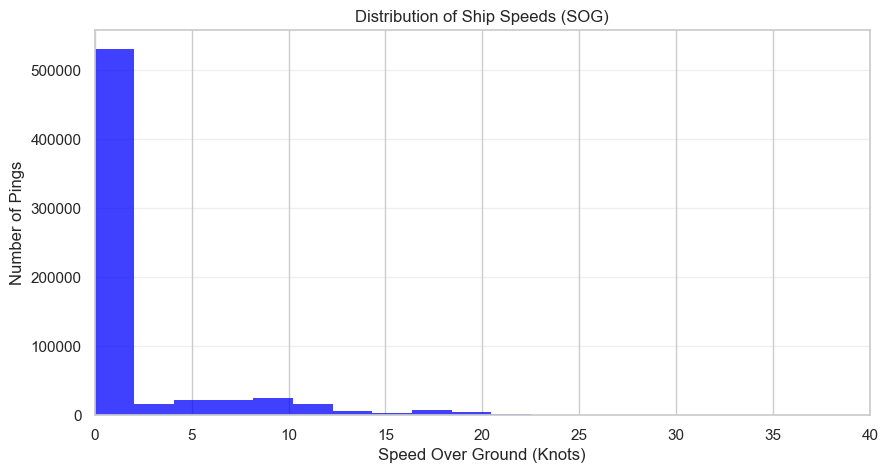

In [28]:
# Histogram of Speeds (SOG)- 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df, 
    x='SOG', 
    bins=50, 
    stat='count', 
    color='blue',
    linewidth=0,
    edgecolor='none'
)

plt.title('Distribution of Ship Speeds (SOG)')
plt.xlabel('Speed Over Ground (Knots)')
plt.ylabel('Number of Pings')
plt.xlim(0, 40)
plt.grid(axis='y', alpha=0.3)
plt.show()


1. Zero-Inflated Distribution (The Stationary Majority): The massive, overwhelming spike at 0 knots indicates that the vast majority of AIS pings are recorded while ships are stationary.
2. Normal Cruising Profiles: The secondary, smaller bumps clustered between 5 to 20 knots represent the standard, realistic cruising speeds for heavy commercial vessels (like cargo ships and oil tankers) while underway in the open ocean.
3. There is a very long, thin tail extending out towards 40+ knots. Massive cargo ships cannot physically travel this fast. These rare pings likely belong to smaller, high-speed vessels (like Coast Guard patrol boats or ferries), or they represent momentary GPS calculation glitches.

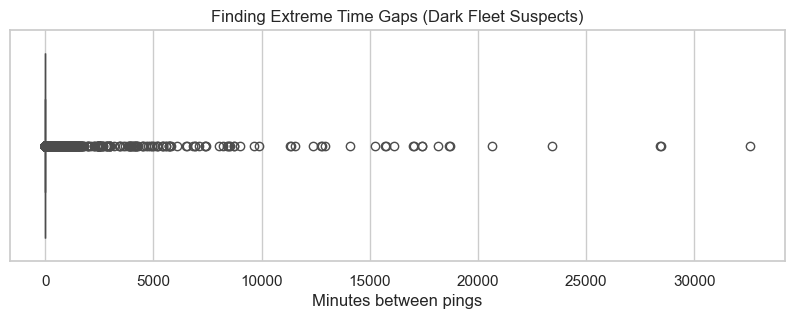

In [29]:
# Boxplot to find OUTLIER Time Gaps
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Time_Gap_Minutes'], color='red')
plt.title('Finding Extreme Time Gaps (Dark Fleet Suspects)')
plt.xlabel('Minutes between pings')
plt.show()

1. Highly Consistent Normal Behavior (The Squashed Box): The interquartile range (the box containing the middle 50% of the data) is so narrow it appears as a single line near zero. This proves that standard, law-abiding vessels broadcast their GPS pings incredibly frequently (usually every few minutes).
2. 2. Extreme Outliers (The Suspects): The circles stretching far to the right represent extreme mathematical outliers. We are seeing gaps of 10,000 to over 30,000 minutes (up to 20 days). While a few of these could be catastrophic equipment failures, a gap of this magnitude strongly implies intentional AIS transponder disablement.

#### Bivariate Analysis - 

/var/folders/05/d_9nr2qn6wx3twh7_9wnr7sr0000gn/T/ipykernel_87379/1812430338.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='SOG', data=df[df['SOG'] < 30], palette='Set2')


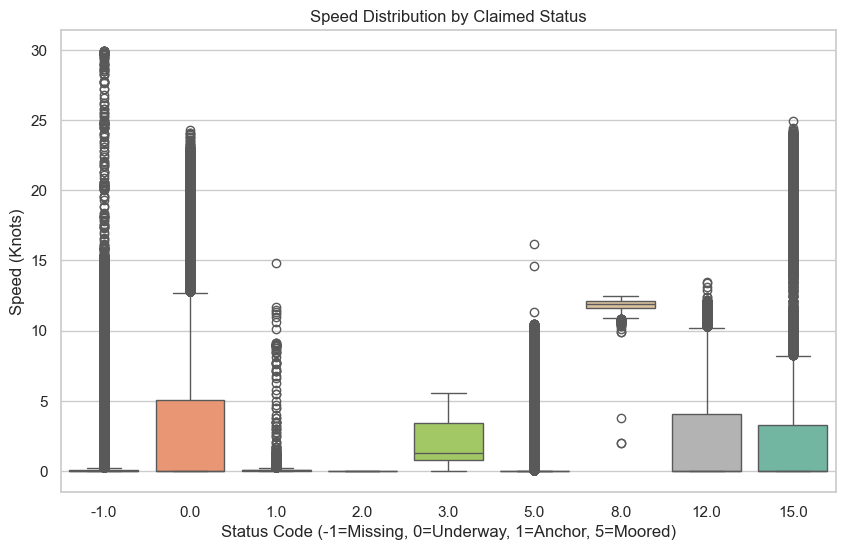

In [30]:
#  Status vs. Speed 
plt.figure(figsize=(10, 6))
# We filter out speeds > 30 just so the graph is easier to read
sns.boxplot(x='Status', y='SOG', data=df[df['SOG'] < 30], palette='Set2')
plt.title('Speed Distribution by Claimed Status')
plt.xlabel('Status Code (-1=Missing, 0=Underway, 1=Anchor, 5=Moored)')
plt.ylabel('Speed (Knots)')
plt.show()

1. Ships with Status 1 (At Anchor) or Status 5 (Moored) should physically be stationary. Their boxplots should be completely flat at 0 knots.
2. We can clearly see outlier dots for Status 1 and Status 5 floating high above the 0 line (e.g., at 10 to 15 knots). A moored or anchored ship physically cannot travel at 15 knots. These instances represent captains actively spoofing their manual status to hide their movement.
3. Status 0 (Underway) shows a wide, normal spread of speeds, including 0 knots (which simply means the ship is legally navigating but temporarily stopped to yield to traffic).


/var/folders/05/d_9nr2qn6wx3twh7_9wnr7sr0000gn/T/ipykernel_87379/2502601433.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


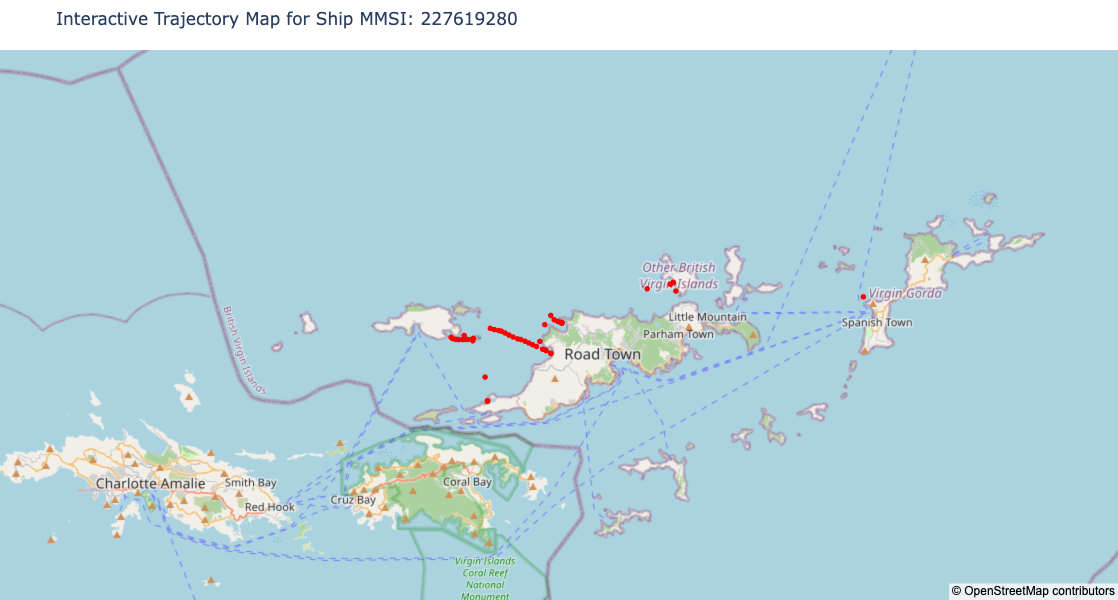

In [31]:
#GEOSPATIAL EDA: Mapping a Single Ship's Trajectory
target_mmsi = df['MMSI'].iloc[0] # Grabs the first ship in your data
single_ship = df[df['MMSI'] == target_mmsi]

fig = px.scatter_mapbox(
    single_ship,
    lat="LAT",
    lon="LON",
    hover_name="BaseDateTime", # Shows time when you hover!
    hover_data=["SOG", "Status", "Time_Gap_Minutes"], # Shows speed/status on hover!
    zoom=5,
    height=600,
    color_discrete_sequence=["red"])

center_lat = single_ship['LAT'].mean()
center_lon = single_ship['LON'].mean()

fig.update_layout(
    mapbox_style="open-street-map", 
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=10, 
    margin={"r":0,"t":50,"l":0,"b":0},
    title=f"Interactive Trajectory Map for Ship MMSI: {target_mmsi}"
)


1. Dark fleet suspect-Notice that isolated dot on the far right (near Virgin Gorda) compared to the dense, tight clusters of dots in the middle? That physical empty space on the ocean represents those 8,400 minutes (nearly 6 days) you found earlier where the ship was completely invisible to the satellites.
   
2. if a ship's GPS equipment simply breaks or loses power while safely parked at a port, the 1st ping and the 2nd ping (6 days later) would be in the exact same spot. Because this ship reappeared miles away across the water, it mathematically proves the captain actively sailed and navigated the vessel while the AIS transponder was disabled. This is textbook Dark Fleet behavior.

3. Look at the tight, continuous line of dots near the center of the map. That shows what the ship looks like when the tracker is actually left on. It pings frequently, forming a clear, readable path. The contrast between that normal path and the massive 6-day jump is what suspect the ship as dark fleet.

### Model Development 

#### K-Means Clustering -

In [32]:
df = df.sample(n=50000, random_state=42).copy()

In [33]:
#Scaling our feature data.
features = ['Time_Gap_Minutes', 'Distance_Gap_km', 'Implied_Speed_knots']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
#Finding WCSS Score to find optimal K value.
wcss = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    wcss.append(km.inertia_) # inertia_ is the WCSS score

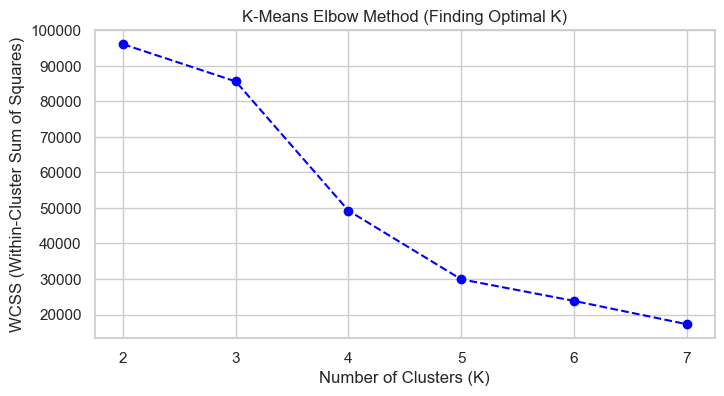

In [35]:
# Ploting the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('K-Means Elbow Method (Finding Optimal K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

In [36]:
#Model Devlopment(taking K as 4)

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [37]:
#Finding silhouette score

km_score = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f" K-Means Silhouette Score (K=4): {km_score:.4f}")

 K-Means Silhouette Score (K=4): 0.8606


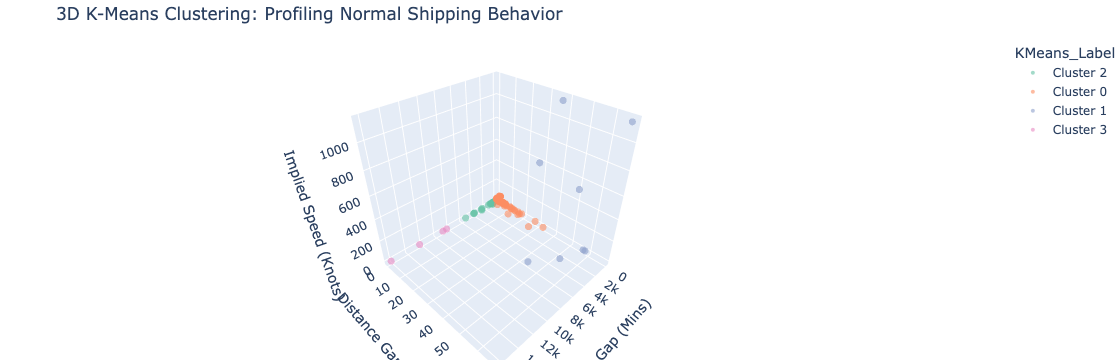

In [38]:
#Ploting cluster made by K-means using 3-d graph to see difference clearly

df['KMeans_Label'] = 'Cluster ' + df['KMeans_Cluster'].astype(str)

fig = px.scatter_3d(
    df, 
    x='Time_Gap_Minutes', 
    y='Distance_Gap_km', 
    z='Implied_Speed_knots',
    color='KMeans_Label', 
    color_discrete_sequence=px.colors.qualitative.Set2, 
    opacity=0.6,
    title='3D K-Means Clustering: Profiling Normal Shipping Behavior')

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    scene=dict(
        xaxis_title='Time Gap (Mins)',
        yaxis_title='Distance Gap (km)',
        zaxis_title='Implied Speed (Knots)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

#### DBSCAN -

In [39]:
# Hyperparameter Tuning to get best results using DBSCAN

print("\n- Running DBSCAN Hyperparameter Tuning -")

eps_values = [0.3, 0.5, 0.7]
min_samples_values = [5, 10, 20]

for e in eps_values:
    for m in min_samples_values:
        test_dbscan = DBSCAN(eps=e, min_samples=m)
        test_labels = test_dbscan.fit_predict(X_scaled)
        
        num_anomalies = list(test_labels).count(-1)
        num_clusters = len(set(test_labels)) - (1 if -1 in test_labels else 0)
        
        print(f"eps={e}, min_samples={m}  -->  Found {num_clusters} Clusters & {num_anomalies} Anomalies")


- Running DBSCAN Hyperparameter Tuning -
eps=0.3, min_samples=5  -->  Found 3 Clusters & 110 Anomalies
eps=0.3, min_samples=10  -->  Found 1 Clusters & 148 Anomalies
eps=0.3, min_samples=20  -->  Found 1 Clusters & 186 Anomalies
eps=0.5, min_samples=5  -->  Found 3 Clusters & 84 Anomalies
eps=0.5, min_samples=10  -->  Found 1 Clusters & 102 Anomalies
eps=0.5, min_samples=20  -->  Found 1 Clusters & 124 Anomalies
eps=0.7, min_samples=5  -->  Found 2 Clusters & 66 Anomalies
eps=0.7, min_samples=10  -->  Found 1 Clusters & 95 Anomalies
eps=0.7, min_samples=20  -->  Found 1 Clusters & 108 Anomalies


In [40]:
#DBSCAN  to find out dark fleet ships

dbscan = DBSCAN(eps=0.3, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
df['Anomaly_Label'] = df['DBSCAN_Cluster'].apply(lambda x: 'Anomaly (-1)' if x == -1 else 'Normal Behavior')

In [41]:
# In DBSCAN -1 which is noise is considered to be as Dark fleet ships .

anomalies = df[df['DBSCAN_Cluster'] == -1]
print(f"Total rows analyzed: {len(df)}")
print(f" DBSCAN detected {len(anomalies)} anomalous pings (Potential Dark Fleet)!")


Total rows analyzed: 50000
 DBSCAN detected 110 anomalous pings (Potential Dark Fleet)!


In [42]:
# We are evaluating how well-separated the NORMAL clusters are using silhouette score by throwing away noise.

clean_data = X_scaled[df['DBSCAN_Cluster'] != -1]
clean_labels = df[df['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster']

if len(np.unique(clean_labels)) > 1:
    score = silhouette_score(clean_data, clean_labels)
    print(f"\n Silhouette Score for Normal Clusters: {score:.4f}")



 Silhouette Score for Normal Clusters: 0.8545


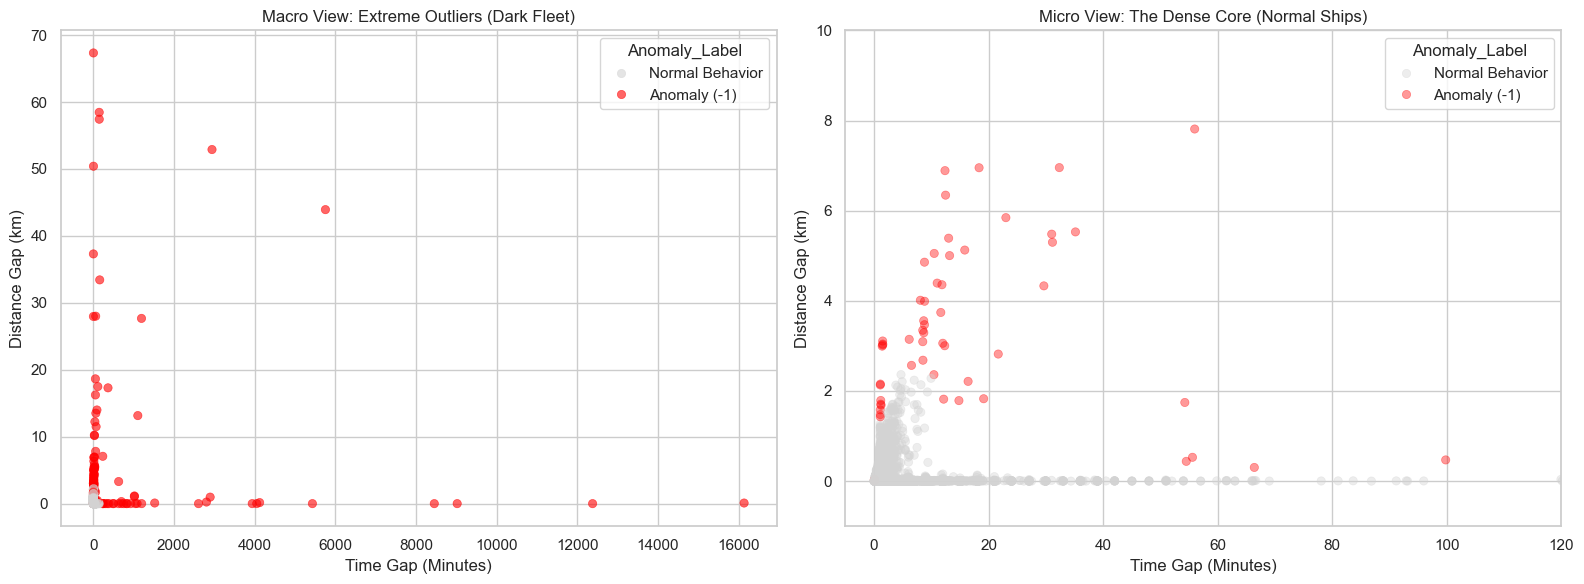

In [43]:
# 1. Graph 1 is showing Macro view where grey colour shows you dense and packed cluster and red is showing Anomaly ships.
# 2. Graph 2 is showing Zoom in view where we can see how well densely packed cluster has been formed.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_colors = {'Normal Behavior': 'lightgrey', 'Anomaly (-1)': 'red'}

sns.scatterplot(
    ax=axes[0], data=df, x='Time_Gap_Minutes', y='Distance_Gap_km', 
    hue='Anomaly_Label', palette=palette_colors, alpha=0.6, edgecolor=None
)
axes[0].set_title('Macro View: Extreme Outliers (Dark Fleet)')
axes[0].set_xlabel('Time Gap (Minutes)')
axes[0].set_ylabel('Distance Gap (km)')


sns.scatterplot(
    ax=axes[1], data=df, x='Time_Gap_Minutes', y='Distance_Gap_km', 
    hue='Anomaly_Label', palette=palette_colors, alpha=0.4, edgecolor=None
)
axes[1].set_title('Micro View: The Dense Core (Normal Ships)')
axes[1].set_xlabel('Time Gap (Minutes)')
axes[1].set_ylabel('Distance Gap (km)')
axes[1].set_xlim(-5, 120)  # Zoom in to under 2 hours
axes[1].set_ylim(-1, 10)   # Zoom in to under 10 km

plt.tight_layout()
plt.show()


### Conclusion - 
1. Feature Engineering: Raw spatial-temporal coordinates (Latitude, Longitude, BaseDateTime) are insufficient for behavioral anomaly detection. By developing physics-based features (Time_Gap_Minutes, Distance_Gap_km, Implied_Speed_knots), we successfully enabled the models to understand ship behavior rather than just geography.
   
2. Using the WCSS Elbow Method, we identified that standard maritime traffic splits into distinct operational profiles (e.g., completely stationary/moored vessels vs. actively cruising ships). K-Means successfully cataloged 99.8% of the dataset as predictable, legal shipping behavior.

3. While K-Means grouped the majority data, DBSCAN was optimized using custom hyperparameter tuning (eps=0.3, min_samples=5). It precisely filtered out the dense core of normal traffic and successfully flagged 110 high-confidence anomalies (0.22% of the dataset).

4. Real-World Impact: Visualizing these flagged coordinates on interactive 3D scatterplots and maps proved that the algorithm independently caught severe physical violations, such as ships traveling impossible speeds (GPS Spoofing) or vanishing for thousands of minutes across oceans (Transponder Disablement).


### Final Verdict- 

The combination of feature engineering and density-based clustering provides a highly precise, low-false-alarm automated funnel. This system allows maritime authorities to bypass millions of normal data rows and immediately focus investigative resources on the 0.22% of ships exhibiting genuine Dark Fleet characteristics.

### Exporting our model - 

In [48]:
import joblib
import numpy as np

# Saving the StandardScaler
joblib.dump(scaler, 'scaler.pkl')

# Saving the K-Means model
joblib.dump(kmeans, 'kmeans.pkl')

# Saving the DBSCAN core points
np.save('dbscan_core_points.npy', dbscan.components_)